# Nonlinear spin conductivity and the X-wave index of altermagnets
The spin splitting of an X-wave collinear magnet is a harmonic of order $l+1$ in reciprocal
space: $k_x$ for p-wave, $k_xk_y$ for d-wave, $k_x(k_x^2-3k_y^2)$ for f-wave,
$k_xk_y(k_x^2-k_y^2)$ for g-wave and $k_xk_y(3k_x^2-k_y^2)(k_x^2-3k_y^2)$ for i-wave. In the
semiclassical Boltzmann treatment, the $l$-th order nonlinear Drude spin conductivity, the
spin current at order $l$ in the electric field, is a Brillouin-zone integral of the
$(l+1)$-th derivative of the band energy, so that it vanishes at every order below $l$ and
switches on at $l$. Reading off the lowest order at which a spin current appears identifies
the wave index, $l=0,1,2,3,5$ for p, d, f, g and i, electrically and with no spin-orbit
coupling at all. `h.get_nonlinear_drude_orders()` returns, for each order up to `lmax`, the
largest spin conductivity over every component of that order, and the X-wave models are
`specialhamiltonian.xwave_magnet(wave=...)`, on the square lattice for p, d and g and on the
triangular lattice for f and i ([arXiv:2411.16036](https://arxiv.org/abs/2411.16036)).
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import specialhamiltonian

### The five X-wave magnets
Let us first look at the spin splitting $E_\uparrow(k)-E_\downarrow(k)$ of each model over
reciprocal space, obtained by keeping one spin channel at a time with `h.remove_spin()`. It
changes sign two times around $\Gamma$ for p-wave, four times for d-wave, six for f-wave,
eight for g-wave and twelve for i-wave. The dashed line is the
Fermi surface at the chemical potential used below, half a hopping above the band bottom,
which is where the conductivity samples the splitting.

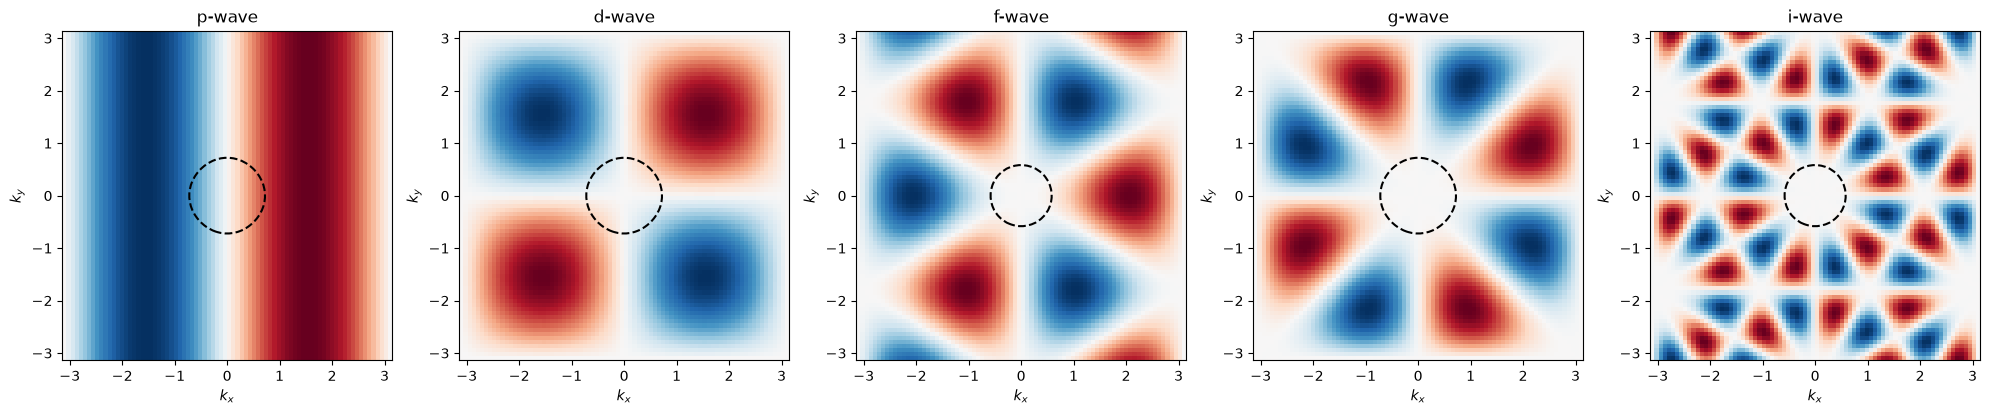

In [2]:
waves = ["p","d","f","g","i"]
bottom = {"p":-4.,"d":-4.,"f":-6.,"g":-4.,"i":-6.} # band bottom for t = -1
nk = 80
ks = np.linspace(-np.pi,np.pi,nk) # Cartesian momenta
fig,axs = plt.subplots(1,5,figsize=(20,4))
for (ax,wave) in zip(axs,waves):
    h = specialhamiltonian.xwave_magnet(wave=wave,J=0.3,t=-1.) # X-wave magnet
    hup = h.copy() ; hup.remove_spin(channel="up") # spin-up channel
    hdn = h.copy() ; hdn.remove_spin(channel="dn") # spin-down channel
    fup = hup.get_hk_gen() ; fdn = hdn.get_hk_gen() # Bloch Hamiltonians
    a1 = np.array(h.geometry.a1) ; a2 = np.array(h.geometry.a2)
    eup = np.zeros((nk,nk)) ; edn = np.zeros((nk,nk))
    for (i,kx) in enumerate(ks):
        for (j,ky) in enumerate(ks):
            kc = np.array([kx,ky,0.])
            kr = [kc.dot(a1)/(2.*np.pi),kc.dot(a2)/(2.*np.pi),0.] # reduced coordinates
            eup[i,j] = fup(kr)[0,0].real ; edn[i,j] = fdn(kr)[0,0].real
    split = eup - edn
    smax = np.max(np.abs(split))
    ax.imshow(split.T,origin="lower",cmap="RdBu_r",vmin=-smax,vmax=smax,
            extent=[ks[0],ks[-1],ks[0],ks[-1]])
    ax.contour(ks,ks,((eup+edn)/2.).T,levels=[bottom[wave]+0.5],colors="k",linestyles="dashed")
    ax.set_title(wave+"-wave") ; ax.set_xlabel("$k_x$") ; ax.set_ylabel("$k_y$")
plt.tight_layout()
plt.show()

### The order at which the spin current switches on
For each model we compute the largest spin conductivity of every order $l$ from 0 to 6, with
the chemical potential half a hopping above the band bottom, so that the system is a metal.
The map shows it on a logarithmic scale, with the orders where it vanishes to machine
precision marked as zero, and the square is the order where the X-wave index says the
response should switch on. Every order to the left of the square is zero, and the orders above it do
not all vanish, because on a lattice the form factor carries higher harmonics beyond the
leading one: it is the absence of every order below the threshold that carries the
information. With the chemical potential in a gap every order vanishes, so the fingerprint
needs a metal.

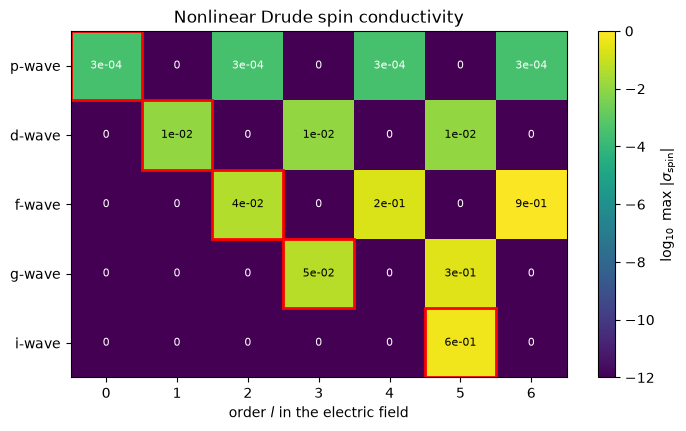

In [3]:
threshold = {"p":0,"d":1,"f":2,"g":3,"i":5} # expected lowest order
table = []
for wave in waves:
    h = specialhamiltonian.xwave_magnet(wave=wave,J=0.3,t=-1.)
    orders = h.get_nonlinear_drude_orders(lmax=6,nk=48,T=0.02,
            mu=bottom[wave]+0.5) # largest |sigma_spin| of each order
    table.append(orders)
table = np.array(table)

plt.figure(figsize=(8,4.5))
plt.imshow(np.log10(np.maximum(table,1e-12)),cmap="viridis",vmin=-12,vmax=0,aspect="auto")
plt.colorbar(label=r"$\log_{10}$ max $|\sigma_{\rm spin}|$")
for (i,wave) in enumerate(waves):
    for l in range(table.shape[1]):
        txt = "0" if table[i,l]<1e-10 else "%.0e" % table[i,l]
        plt.text(l,i,txt,ha="center",va="center",color="w" if table[i,l]<1e-3 else "k",fontsize=8)
    l0 = threshold[wave]
    plt.gca().add_patch(plt.Rectangle((l0-0.5,i-0.5),1,1,fill=False,ec="red",lw=2))
plt.yticks(range(len(waves)),[w+"-wave" for w in waves])
plt.xlabel("order $l$ in the electric field")
plt.title("Nonlinear Drude spin conductivity")
plt.show()